# 利用数值计算的方式验证 DCM 公式

+ Author: Zhu Dengda  
+ Email:  zhudengda@mail.iggcas.ac.cn

In [1]:
import numpy as np
from scipy.special import jv, jvp
import matplotlib.pyplot as plt

In [2]:
a = 1e-2
r = 2.2
kmax, dk = 10000/r, 0.02/r
karr = np.arange(0, kmax, dk)
kr = karr * r
exp = np.exp( - a * karr)

In [3]:
def plot_diff(res, REF, Pm):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(karr, Pm)
    ax.hlines(res, 0, karr[-1], colors='k', ls='--')
    ax.hlines(REF, 0, karr[-1], colors='r')
    ax.grid()

    diff = res - REF
    print("res = ", res)
    print("REF = ", REF)
    print("diff = ", diff)

$\int_0^\infty J_m(kr) dk = \dfrac{1}{r}, \quad m=1,2$

m =  1
res =  0.45247178439137276
REF =  0.45454545454545453
diff =  -0.002073670154081775
m =  2
res =  0.45042731017139676
REF =  0.45454545454545453
diff =  -0.004118144374057775


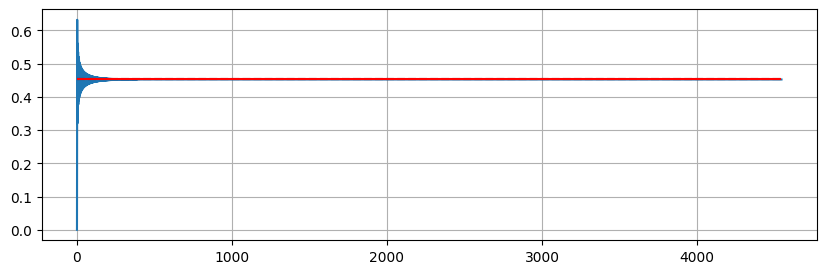

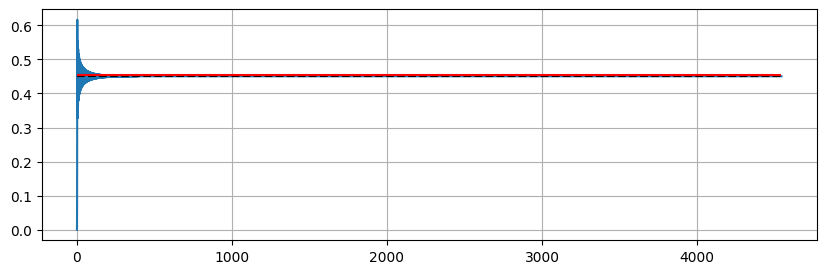

In [4]:
for m in [1, 2]:
    Jm = exp * jv(m, kr)
    Pm = np.cumsum(Jm) * dk
    res = Pm[-1]
    REF = 1 / r

    print("m = ", m)
    plot_diff(res, REF, Pm)

$\int_0^\infty J_0(kr) k dk = 0$

res =  0.0009322272749800605
REF =  0
diff =  0.0009322272749800605


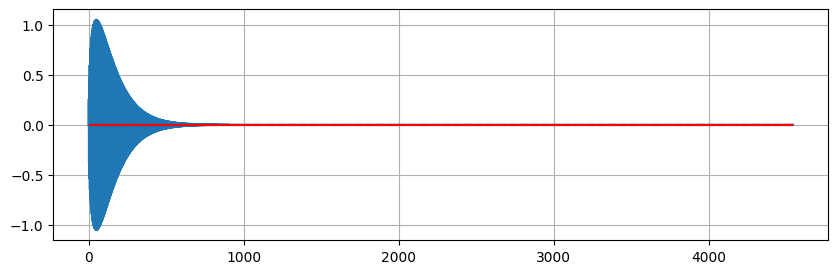

In [5]:
m = 0
Jm = exp * jv(m, kr) * karr
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = 0

plot_diff(res, REF, Pm)

$\int_0^\infty J_1(kr) k dk = \dfrac{1}{r^2}$

res =  0.20660516716155602
REF =  0.20661157024793386
diff =  -6.403086377837486e-06


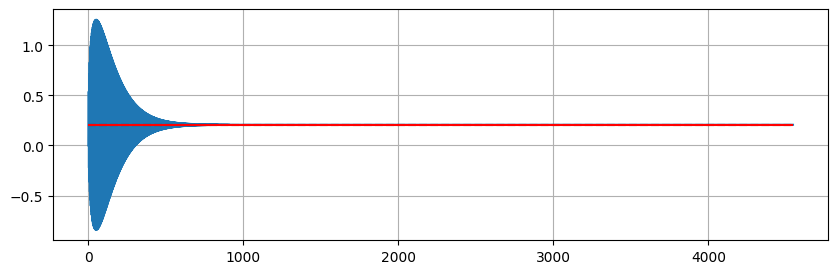

In [6]:
m = 1
Jm = exp * jv(m, kr) * karr
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = 1 / r**2

plot_diff(res, REF, Pm)

$\int_0^\infty J_2(kr) k dk = \dfrac{2}{r^2}$

res =  0.4104057585353301
REF =  0.4132231404958677
diff =  -0.0028173819605376016


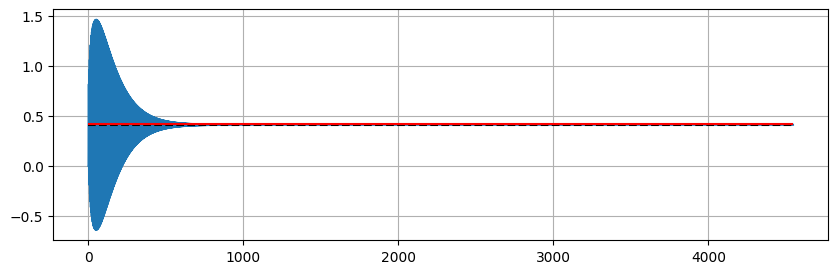

In [7]:
m = 2
Jm = exp * jv(m, kr) * karr
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = 2 / r**2

plot_diff(res, REF, Pm)

$\int_0^\infty J_0^\prime(kr) k^2 dk = 0$

res =  -0.0012805841459082666
REF =  0
diff =  -0.0012805841459082666


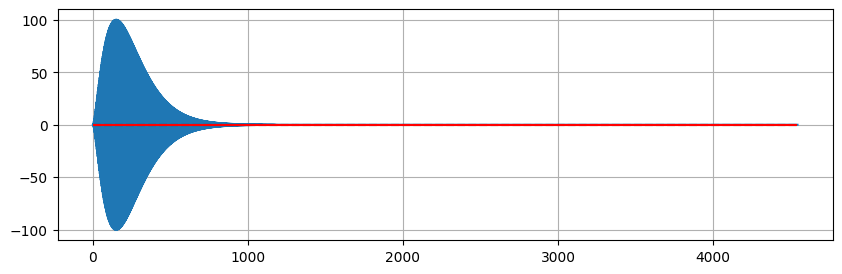

In [8]:
m = 0
Jm = exp * jvp(m, kr) * karr**2
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = 0

plot_diff(res, REF, Pm)

$\int_0^\infty J_1^\prime(kr) k^2 dk = - \dfrac{2}{r^3}$

res =  -0.1878170584017013
REF =  -0.18782870022539438
diff =  1.1641823693092634e-05


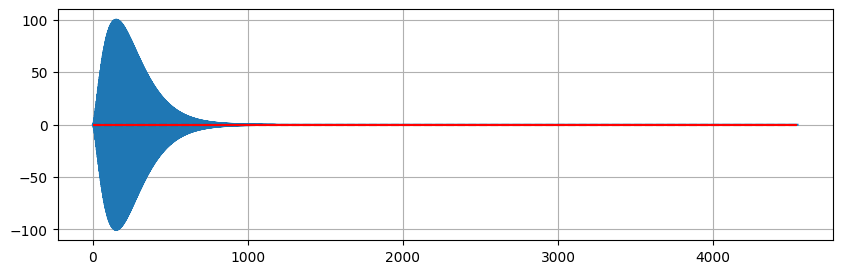

In [9]:
m = 1
Jm = exp * jvp(m, kr) * karr**2
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = - 2 / r**3

plot_diff(res, REF, Pm)

$\int_0^\infty J_2^\prime(kr) k^2 dk = - \dfrac{4}{r^3}$

res =  -0.37181555997747184
REF =  -0.37565740045078877
diff =  0.0038418404733169265


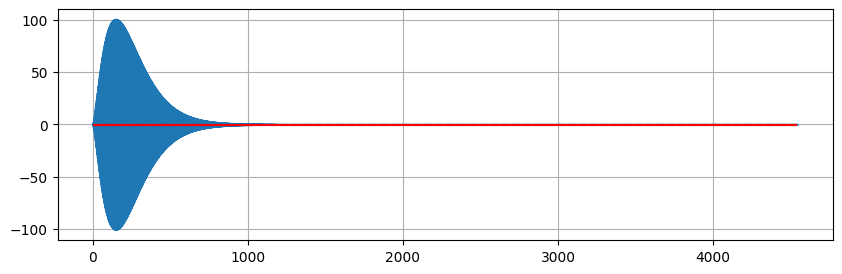

In [10]:
m = 2
Jm = exp * jvp(m, kr) * karr**2
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = - 4 / r**3

plot_diff(res, REF, Pm)

$\int_0^\infty \dfrac{\text{d}}{\text{d}r}\left[ \dfrac{1}{r} J_m(kr) \right] dk = - \dfrac{2}{r^3}, \quad m=1,2$

m =  1
res =  -0.18654807206152557
REF =  -0.18782870022539438
diff =  0.0012806281638688133
m =  2
res =  -0.1852790418923156
REF =  -0.18782870022539438
diff =  0.002549658333078797


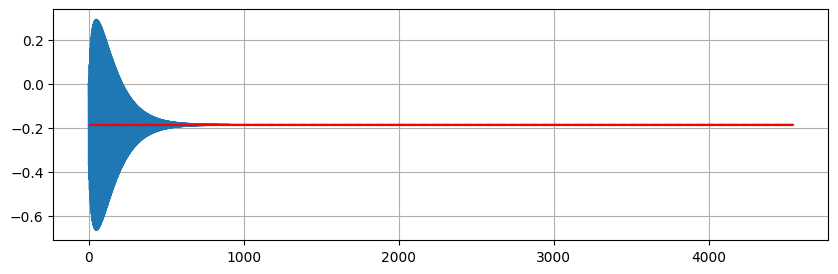

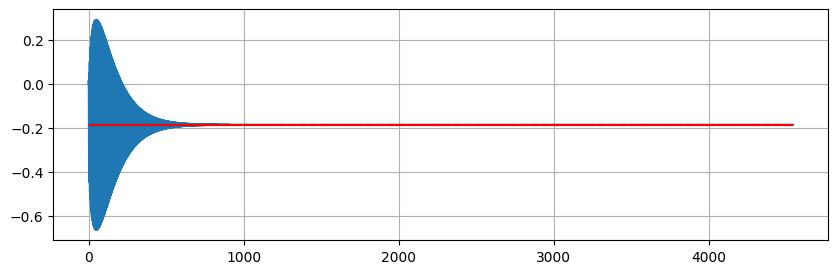

In [11]:
for m in [1, 2]:
    Jm = exp * (1/r * jvp(m, kr) * karr - 1/r**2 * jv(m, kr))
    Pm = np.cumsum(Jm) * dk
    res = Pm[-1]
    REF = - 2 / r**3

    print("m = ", m)
    plot_diff(res, REF, Pm)

$\int_0^\infty J_0(kr) k^2 dk = - \dfrac{1}{r^3}$

res =  -0.0939056187829591
REF =  -0.09391435011269719
diff =  8.731329738095872e-06


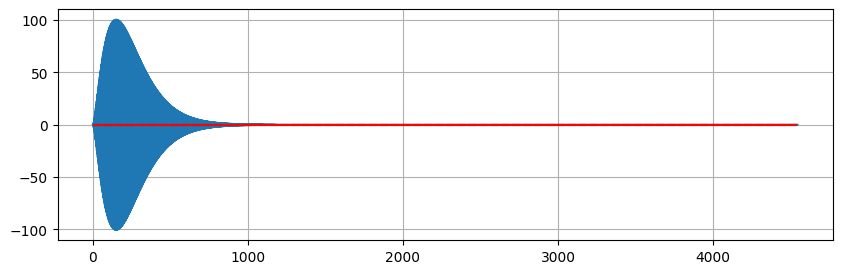

In [12]:
m = 0
Jm = exp * jv(m, kr) * karr**2
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = - 1 / r**3

plot_diff(res, REF, Pm)

$\int_0^\infty J_1(kr) k^2 dk = 0$

res =  0.0012805841459082666
REF =  0
diff =  0.0012805841459082666


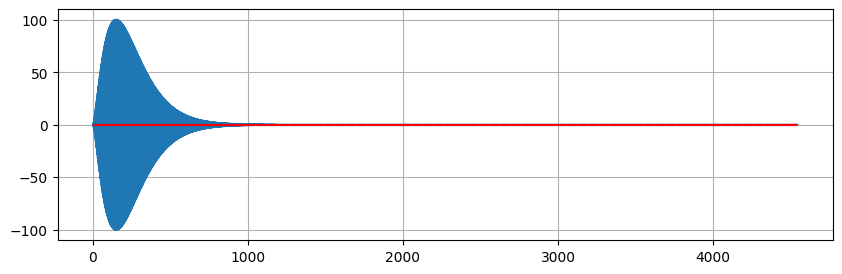

In [13]:
m = 1
Jm = exp * jv(m, kr) * karr**2
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = 0

plot_diff(res, REF, Pm)

$\int_0^\infty J_2(kr) k^2 dk = \dfrac{3}{r^3}$

res =  0.28172849802059835
REF =  0.28174305033809155
diff =  -1.4552317493199407e-05


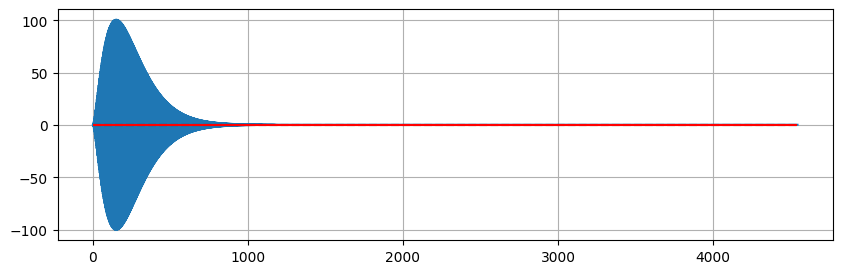

In [14]:
m = 2
Jm = exp * jv(m, kr) * karr**2
Pm = np.cumsum(Jm) * dk
res = Pm[-1]
REF = 3 / r**3

plot_diff(res, REF, Pm)